In [1]:
import json
from datasets import load_dataset

ds = load_dataset("allenai/ai2_arc", "ARC-Challenge")

/home/junseokkim00/.conda/envs/ahaSafe/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ds

DatasetDict({
    train: Dataset({
        features: ['id', 'question', 'choices', 'answerKey'],
        num_rows: 1119
    })
    test: Dataset({
        features: ['id', 'question', 'choices', 'answerKey'],
        num_rows: 1172
    })
    validation: Dataset({
        features: ['id', 'question', 'choices', 'answerKey'],
        num_rows: 299
    })
})

In [3]:
sample = ds['test'][0]

In [4]:
texts , labels = sample['choices']['text'], sample['choices']['label']

In [6]:
question = sample['question'] +'\n\n'
for label, text in zip(labels, texts):
    question += f"{label}. {text}\n"
print(question)
sample['answerKey']

An astronomer observes that a planet rotates faster after a meteorite impact. Which is the most likely effect of this increase in rotation?

A. Planetary density will decrease.
B. Planetary years will become longer.
C. Planetary days will become shorter.
D. Planetary gravity will become stronger.



'C'

In [14]:
arc_test_dataset=[]
for sample in ds['test']:
    answer = sample['answerKey']
    texts , labels = sample['choices']['text'], sample['choices']['label']
    question = sample['question'] +'\n\n'
    for label, text in zip(labels, texts):
        question += f"{label}. {text}\n"
    arc_test_dataset.append({
        "question": question,
        "answer": answer
    })
with open("../arc_challenge/test.jsonl", "w") as f:
    for item in arc_test_dataset:
        f.write(json.dumps(item) + "\n")


In [8]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-3B-Instruct", trust_remote_code=True)

In [9]:
# ds['train'][0]
question_length = []
for item in arc_test_dataset:
    length = len(tokenizer.encode(item['question'], add_special_tokens=False))
    question_length.append(length)
# print(ds['test'][71]['question'])

In [15]:
arc_train_dataset=[]
for sample in ds['train']:
    answer = sample['answerKey']
    texts , labels = sample['choices']['text'], sample['choices']['label']
    question = sample['question'] +'\n\n'
    for label, text in zip(labels, texts):
        question += f"{label}. {text}\n"
    arc_train_dataset.append({
        "question": question,
        "answer": answer
    })
print(len(arc_train_dataset))
with open("../arc_challenge/train.jsonl", "w") as f:
    for item in arc_train_dataset:
        f.write(json.dumps(item) + "\n")


1119


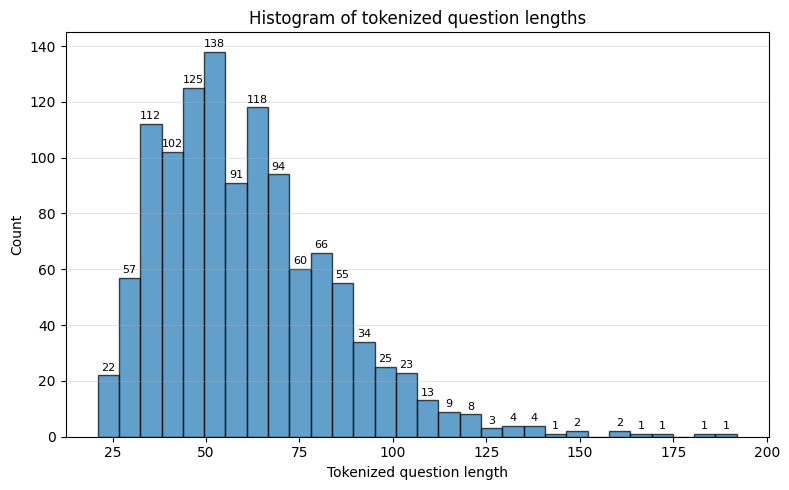

In [10]:
import numpy as np
import matplotlib.pyplot as plt

q = np.array(question_length)

plt.figure(figsize=(8,5))
n, bins, patches = plt.hist(q, bins=30, color='C0', edgecolor='k', alpha=0.7)
plt.xlabel('Tokenized question length')
plt.ylabel('Count')
plt.title('Histogram of tokenized question lengths')
plt.grid(axis='y', alpha=0.3)

# add count labels above each bar
for p, count in zip(patches, n):
    if count > 0:
        x = p.get_x() + p.get_width() / 2
        plt.text(x, count + 1, str(int(count)), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()